In [ ]:
# немного расширяем рабочую область ноутбука
from IPython.display import HTML
display(HTML("<style>.container { width:92% !important; }</style>"))


<h2 style="text-align: center;"><b>Занятие: Проблемы качества данных</b></h2>


## <h1><u>План урока</u></h1>


1. Что считаем проблемой качества данных
2. Базовая проверка датасета
3. Обнаружим проблемы
4. Метрика качества диагностики
5. Очистка данных: минимально необходимый пайплайн
6. Как плохие данные искажают моделирование


### <h3><b>1. Что считаем проблемой качества данных</b></h3>

Проблемы, которые будем искать:
- пропуски (missing values),
- дубликаты строк,
- некорректные значения (нарушение диапазона),
- несоответствия категорий (грязные категории),
- выбросы (outliers).



In [1]:
# импорт базовых библиотек
import numpy as np  # численные операции
import pandas as pd  # таблицы и анализ

# импорт датасета из библиотеки
from sklearn.datasets import load_breast_cancer  # учебный датасет
from sklearn.model_selection import train_test_split  # разбиение train/test
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# импорт графиков
import matplotlib.pyplot as plt  # графики
import seaborn as sns  # статистическая визуализация

# фиксируем генератор случайности
rng = np.random.default_rng(42)


**Мы будем использовать датасет Breast Cancer Wisconsin (Diagnostic)** из sklearn.datasets.load_breast_cancer — классический набор для бинарной классификации опухолей (злокачественная/доброкачественная).

**Ключевые факты:**

- 569 наблюдений и 30 числовых признаков (размер/форма/текстура клеточных ядер, например mean radius, mean texture, mean area).

- Целевая переменная: 2 класса — malignant и benign (в оригинальном распределении 212 и 357 объектов).



В нашем занятии это база, в которую мы специально внесли «грязь» (пропуски, дубликаты, выбросы, грязные категории), чтобы тренировать диагностику качества данных.

In [2]:
# функция: создаём dirty_train и журнал «истинных» проблем
def build_dirty_train(seed=42):
    # локальный генератор
    local_rng = np.random.default_rng(seed)

    # загружаем датасет из sklearn
    data = load_breast_cancer(as_frame=True)
    base_df = data.frame.copy()

    # добавляем категориальный признак
    base_df["scanner_type"] = local_rng.choice(["A", "B", "C"], size=len(base_df), p=[0.45, 0.35, 0.20])

    # берем train-часть
    train_df, _ = train_test_split(
        base_df,
        test_size=0.25,
        random_state=42,
        stratify=base_df["target"]
    )
    train_df = train_df.reset_index(drop=True)

    # копируем в «грязный» датасет
    dirty = train_df.copy()
    issue_rows = []  # журнал проблем

    # 1) пропуски в двух числовых столбцах
    miss_idx = local_rng.choice(dirty.index, size=int(0.15 * len(dirty)), replace=False)
    for col in ["mean radius", "mean texture"]:
        dirty.loc[miss_idx, col] = np.nan
        issue_rows += [(int(i), col, "missing") for i in miss_idx]

    # 2) нарушение диапазона: mean radius < 0
    remain_idx = np.setdiff1d(dirty.index.values, miss_idx)
    neg_idx = local_rng.choice(remain_idx, size=30, replace=False)
    dirty.loc[neg_idx, "mean radius"] = -dirty.loc[neg_idx, "mean radius"].abs()
    issue_rows += [(int(i), "mean radius", "range_violation") for i in neg_idx]

    # 3) искусственные выбросы по mean area
    out_idx = local_rng.choice(dirty.index, size=25, replace=False)
    dirty.loc[out_idx, "mean area"] = dirty["mean area"].median() * 20
    issue_rows += [(int(i), "mean area", "outlier") for i in out_idx]

    # 4) грязные категории scanner_type
    bad_vals = np.array(["a ", "Type-A", "scanner_c", "B ", "unknown"])
    cat_idx = local_rng.choice(dirty.index, size=40, replace=False)
    dirty.loc[cat_idx, "scanner_type"] = local_rng.choice(bad_vals, size=len(cat_idx), replace=True)
    issue_rows += [(int(i), "scanner_type", "category_inconsistency") for i in cat_idx]

    # 5) дубликаты строк
    dup_part = dirty.sample(n=100, random_state=seed)
    start = len(dirty)
    dirty = pd.concat([dirty, dup_part], ignore_index=True)
    dup_new_idx = list(range(start, start + len(dup_part)))
    issue_rows += [(int(i), "*", "duplicate_row") for i in dup_new_idx]

    # формируем журнал истинных проблем
    issue_log = pd.DataFrame(issue_rows, columns=["row_id", "column", "issue_type"]).drop_duplicates()

    # возвращаем грязный датасет, журнал и чистую train-базу (для сравнений статистик)
    return dirty, issue_log, train_df


In [3]:
# «импортируем» dirty_train (создаём грязный датасет)
dirty_train, issue_log, train_ref = build_dirty_train(seed=42)

# быстрый просмотр
print("dirty_train shape:", dirty_train.shape)
print("issue_log size:", len(issue_log))
dirty_train.head()


dirty_train shape: (526, 32)
issue_log size: 321


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,scanner_type
0,19.89,20.26,130.50,1214.0,0.10370,0.13100,0.1411,0.09431,0.1802,0.06188,...,160.5,1646.0,0.14170,0.3309,0.4185,0.16130,0.2549,0.09136,0,scanner_c
1,12.89,13.12,81.89,515.9,0.06955,0.03729,0.0226,0.01171,0.1337,0.05581,...,87.4,577.0,0.09616,0.1147,0.1186,0.05366,0.2309,0.06915,1,A
2,-17.14,16.40,116.00,912.7,0.11860,0.22760,0.2229,0.14010,0.3040,0.07413,...,152.4,1461.0,0.15450,0.3949,0.3853,0.25500,0.4066,0.10590,0,A
3,NaN,NaN,113.00,928.2,0.10080,0.10410,0.1266,0.08353,0.1813,0.05613,...,130.9,1222.0,0.14160,0.2405,0.3378,0.18570,0.3138,0.08113,0,A
4,22.01,21.90,147.20,1482.0,0.10630,0.19540,0.2448,0.15010,0.1824,0.06140,...,195.0,2227.0,0.12940,0.3885,0.4756,0.24320,0.2741,0.08574,0,C


### <h3><b>2. Базовая проверка датасета</b></h3>

Перед поиском сложных проблем всегда делаем быструю проверку:

1. Проверяем **размер датасета** (`shape`) и смотрим **типы столбцов** (`dtypes`), чтобы понять структуру данных.  
2. Считаем **долю пропусков** по каждому признаку и выводим топ столбцов с наибольшим количеством `NaN`.  
3. Смотрим **уникальные значения** в `scanner_type`, чтобы выявить «грязные» категории (лишние пробелы, разные форматы записи, неизвестные значения).

Это нужно, чтобы за 1 шаг найти основные проблемы качества данных перед детальной очисткой.


In [ ]:
# размер и типы
print("Размер dirty_train:", dirty_train.shape)
print("\nТипы столбцов:")
print(dirty_train.dtypes.tail(5))  # последние 5 для компактности

# доля пропусков
print("\nТоп столбцов по пропускам (%):")
print((dirty_train.isna().mean() * 100).round(2).sort_values(ascending=False).head(10))

# уникальные значения категориального столбца
print("\nУникальные scanner_type:")
print(sorted(dirty_train["scanner_type"].astype(str).unique())[:15])


Размер dirty_train: (526, 32)

Типы столбцов:
worst concave points       float64
worst symmetry             float64
worst fractal dimension    float64
target                       int64
scanner_type                object
dtype: object

Топ столбцов по пропускам (%):
mean radius               14.64
mean texture              14.64
mean perimeter             0.00
mean area                  0.00
mean smoothness            0.00
mean compactness           0.00
mean concavity             0.00
mean concave points        0.00
mean symmetry              0.00
mean fractal dimension     0.00
dtype: float64

Уникальные scanner_type:
['A', 'B', 'B ', 'C', 'Type-A', 'a ', 'scanner_c', 'unknown']


### <h3><b>3. Обнаружим проблемы</b></h3>


Мы задаём **набор правил**, которые автоматически находят типовые проблемы в данных.  
Все функции возвращают результат в едином формате:

`(row_id, column, issue_type)`

Это нужно, чтобы:
1. объединять результаты разных детекторов,
2. не дублировать одни и те же находки (используем `set`),

---


##### `detect_missing(df)`
Ищет пропуски (`NaN`) во всех столбцах через `df.isna()` и `np.where`.  
Возвращает координаты пропусков: в какой строке и в каком столбце проблема.

##### `detect_duplicates(df)`
Находит полные дубликаты строк (`df.duplicated(keep="first")`).  
Первую встреченную строку считаем эталонной, повторные — проблемными.

##### `detect_range_violations(df)`
Проверяет бизнес-правило диапазона: `mean radius` не может быть < 0.  
Такие значения считаются физически невозможными и помечаются как ошибка.

##### `detect_category_inconsistency(df)`
Проверяет категориальный столбец `scanner_type` по whitelist (`ALLOWED_SCANNERS`).  
Любые нестандартные значения (`"a "`, `"Type-A"`, `"unknown"` и т.д.) помечаются как несоответствия.

##### `detect_outliers_iqr(df, col="mean area", k=1.5)`
Ищет выбросы по правилу IQR (межквартильного размаха):
- `Q1`, `Q3`,
- `IQR = Q3 - Q1`,
- границы: `[Q1 - k*IQR, Q3 + k*IQR]`.

Значения за пределами границ помечаются как `outlier`.  
Этот метод устойчив к выбросам и хорошо подходит для первичной диагностики.

---

#### Зачем мы это делаем перед моделированием

- повышаем корректность данных для обучения;
- убираем системные искажения (дубликаты, «грязные» категории, невозможные значения);
- уменьшаем риск нестабильных выводов из-за выбросов и пропусков;
- формализуем контроль качества: можно измерить, сколько проблем реально найдено.



In [ ]:
 # допустимые «чистые» категории
ALLOWED_SCANNERS = {"A", "B", "C"}

# детектор пропусков
def detect_missing(df):
    rows, cols = np.where(df.isna())
    return {(int(r), df.columns[c], "missing") for r, c in zip(rows, cols)}

# детектор дубликатов (берём повторные строки)
def detect_duplicates(df):
    dup_idx = df.index[df.duplicated(keep="first")]
    return {(int(i), "*", "duplicate_row") for i in dup_idx}

# детектор нарушений диапазона
def detect_range_violations(df):
    mask = df["mean radius"] < 0
    return {(int(i), "mean radius", "range_violation") for i in df.index[mask]}

# детектор грязных категорий
def detect_category_inconsistency(df):
    mask = ~df["scanner_type"].isin(ALLOWED_SCANNERS)
    return {(int(i), "scanner_type", "category_inconsistency") for i in df.index[mask]}

# детектор выбросов через IQR
def detect_outliers_iqr(df, col="mean area", k=1.5):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    mask = (df[col] < low) | (df[col] > high)
    return {(int(i), col, "outlier") for i in df.index[mask]}


In [ ]:
# запускаем все детекторы
detected_set = set().union(
    detect_missing(dirty_train),
    detect_duplicates(dirty_train),
    detect_range_violations(dirty_train),
    detect_category_inconsistency(dirty_train),
    detect_outliers_iqr(dirty_train, col="mean area", k=1.5)
)

# переводим в DataFrame
detected_df = pd.DataFrame(list(detected_set), columns=["row_id", "column", "issue_type"])

# сколько нашли по типам
detected_df["issue_type"].value_counts()


,count
issue_type,
missing,154
duplicate_row,100
category_inconsistency,51
outlier,41
range_violation,40


### <h3><b> 4. Метрика качества диагностики (recall)</b></h3>

Оцениваем, какую долю реальных проблем мы нашли:

Recall = TP / TP + FN

где:
- TP — проблемы, которые действительно были и мы их нашли,
- FN — проблемы, которые были, но мы их пропустили.



In [ ]:
# формируем множества «истина» и «нашли»
true_set = set(issue_log.itertuples(index=False, name=None))
found_set = set(detected_df.itertuples(index=False, name=None))

# считаем TP и recall
tp_set = true_set & found_set
recall = len(tp_set) / len(true_set)

# печатаем итог
print(f"Всего истинных проблем: {len(true_set)}")
print(f"Найдено корректно (TP): {len(tp_set)}")
print(f"Recall: {recall:.2%}")


Всего истинных проблем: 321
Найдено корректно (TP): 321
Recall: 100.00%


In [ ]:
# детализация recall по каждому типу проблемы
tp_df = pd.DataFrame(list(tp_set), columns=["row_id", "column", "issue_type"])

by_type = (
    issue_log.groupby("issue_type").size().rename("true_count").to_frame()
    .join(tp_df.groupby("issue_type").size().rename("tp_count"), how="left")
    .fillna(0)
)

by_type["tp_count"] = by_type["tp_count"].astype(int)
by_type["recall"] = (by_type["tp_count"] / by_type["true_count"]).round(3)

by_type.sort_values("recall", ascending=False)


,true_count,tp_count,recall
issue_type,,,
category_inconsistency,40,40,1.0
duplicate_row,100,100,1.0
missing,126,126,1.0
outlier,25,25,1.0
range_violation,30,30,1.0


### <h3><b>5. Очистка данных: минимально необходимый пайплайн</b></h3>

Функция ниже реализует **базовый пайплайн очистки данных** перед моделированием.  
Цель: привести `dirty_train` к консистентному виду, чтобы снизить шум и искажения в признаках.

Функция работает по шагам:

1. **Удаление дубликатов**  
   `drop_duplicates(keep="first")` удаляет повторные строки, оставляя первое вхождение.  
   Это предотвращает переучёт одних и тех же наблюдений и смещение статистик.

2. **Нормализация категорий `scanner_type`**  
   - `str.strip()` убирает лишние пробелы (`"a "` → `"a"`),  
   - `cat_map` приводит разные варианты записи к единому стандарту (`"Type-A"` → `"A"`),  
   - всё, что не входит в допустимые категории `ALLOWED_SCANNERS`, переводится в `NaN`,  
   - затем пропуски категорий заполняются **модой** (самым частым значением).  
   Это уменьшает «раздутие» числа категорий и делает признак пригодным для кодирования.

3. **Обработка невозможных значений**  
   Для `mean radius < 0` значение считается некорректным и заменяется на `NaN`.  
   Логика: сначала отмечаем ошибку как пропуск, потом заполняем единообразно.

4. **Ограничение выбросов (IQR capping)**  
   По признаку `mean area` считаются границы:
   \[
   [Q1 - 1.5 \cdot IQR,\; Q3 + 1.5 \cdot IQR]
   \]
   Затем `clip()` «подрезает» экстремальные значения до границ.  
   Это снижает влияние выбросов без удаления строк.

5. **Импутация числовых пропусков медианой**  
   Для всех числовых столбцов (кроме `target`) пропуски заменяются на медиану столбца.  
   Медиана устойчива к выбросам и обычно надёжна для первичной очистки.

---

**Почему именно такая последовательность**

Сначала убираем структурные проблемы (дубликаты, грязные категории, невозможные значения),  
потом стабилизируем распределения (каппинг выбросов),  
и только после этого заполняем пропуски.

Так мы уменьшаем риск того, что «грязные» значения повлияют на расчёт статистик и на качество обучения модели.


In [ ]:
# функция очистки dirty_train
def clean_quality_issues(df):
    clean = df.copy()

    # 1) удаляем дубликаты
    clean = clean.drop_duplicates(keep="first").reset_index(drop=True)
    

    # 2) чистим и нормализуем категории
    clean["scanner_type"] = clean["scanner_type"].astype(str).str.strip()
    cat_map = {
        "A": "A", "a": "A", "Type-A": "A", "TYPE-A": "A",
        "B": "B", "b": "B",
        "C": "C", "c": "C", "scanner_c": "C", "SCANNER_C": "C"
    }
    clean["scanner_type"] = clean["scanner_type"].replace(cat_map)
    clean.loc[~clean["scanner_type"].isin(ALLOWED_SCANNERS), "scanner_type"] = np.nan
    clean["scanner_type"] = clean["scanner_type"].fillna(clean["scanner_type"].mode()[0])

    # 3) некорректный диапазон -> NaN
    clean.loc[clean["mean radius"] < 0, "mean radius"] = np.nan

    # 4) каппинг выбросов по IQR для mean area
    q1, q3 = clean["mean area"].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    clean["mean area"] = clean["mean area"].clip(lower=low, upper=high)

    # 5) заполняем числовые пропуски медианой
    num_cols = clean.select_dtypes(include="number").columns.tolist()
    if "target" in num_cols:
        num_cols.remove("target")
    clean[num_cols] = clean[num_cols].fillna(clean[num_cols].median())

    return clean


In [ ]:
# применяем очистку
clean_train = clean_quality_issues(dirty_train)

# быстрые проверки после очистки
post_check = {
    "rows": len(clean_train),
    "missing_total": int(clean_train.isna().sum().sum()),
    "duplicate_rows": int(clean_train.duplicated().sum()),
    "range_violations_mean_radius": int((clean_train["mean radius"] < 0).sum()),
    "bad_categories_scanner_type": int((~clean_train["scanner_type"].isin(ALLOWED_SCANNERS)).sum())
}
pd.Series(post_check)


,0
rows,426
missing_total,0
duplicate_rows,0
range_violations_mean_radius,0
bad_categories_scanner_type,0


### <h3><b> 6. Как плохие данные искажают моделирование </b></h3>

Реальные эффекты:
- **Пропуски** → нестабильные оценки и потеря наблюдений.
- **Дубликаты** → переучёт части объектов, смещение важных паттернов.
- **Грязные категории** (`A`, `a `, `Type-A`) → ложное увеличение числа категорий.
- **Невозможные значения** (например, отрицательный радиус) → физически бессмысленные зависимости.
- **Выбросы** → искажение среднего/дисперсии, нестабильность коэффициентов.

Кейсы:
- В скоринге дубликаты «перетягивают» профиль риска.
- В медданных выбросы меняют пороги и клиническую интерпретацию.
- В ритейле грязные категории ломают сегментацию клиентов.


In [ ]:
# считаем ключевые статистики до и после очистки
summary = pd.DataFrame({
    "dirty_mean_area_mean": [dirty_train["mean area"].mean()],
    "clean_mean_area_mean": [clean_train["mean area"].mean()],
    "dirty_mean_area_std": [dirty_train["mean area"].std()],
    "clean_mean_area_std": [clean_train["mean area"].std()],
    "dirty_mean_radius_min": [dirty_train["mean radius"].min()],
    "clean_mean_radius_min": [clean_train["mean radius"].min()],
    "dirty_scanner_nunique": [dirty_train["scanner_type"].nunique()],
    "clean_scanner_nunique": [clean_train["scanner_type"].nunique()],
})

summary.T.rename(columns={0: "value"})


,value
dirty_mean_area_mean,1346.275285
clean_mean_area_mean,689.526115
dirty_mean_area_std,2608.661735
clean_mean_area_std,378.148315
dirty_mean_radius_min,-20.510000
clean_mean_radius_min,6.981000
dirty_scanner_nunique,8.000000
clean_scanner_nunique,3.000000


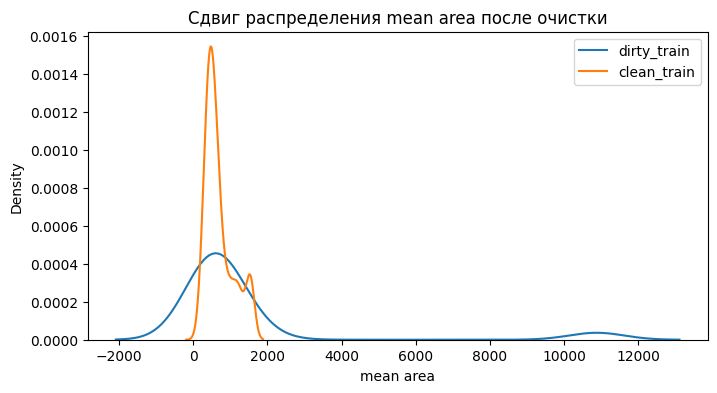

In [ ]:
# визуально: распределение mean area до/после очистки
plt.figure(figsize=(8, 4))  # размер графика
sns.kdeplot(dirty_train["mean area"], label="dirty_train")  # грязные данные
sns.kdeplot(clean_train["mean area"], label="clean_train")  # очищенные данные
plt.title("Сдвиг распределения mean area после очистки")  # заголовок
plt.legend()  # легенда
plt.show()  # показать график


#### Проверка влияния качества данных на модель

Проверим, как «грязные» и «очищенные» данные влияют на результат.

Логика эксперимента:
1. Используем **один и тот же тестовый набор** для честного сравнения.
2. Обучаем одинаковые модели сначала на `dirty_train`, затем на `clean_train`.
3. Сравниваем метрику `accuracy`.

Если качество данных действительно важно, модели на `clean_train` должны показывать более стабильные и, как правило, более высокие метрики.


In [ ]:
def get_acc(df):
    # только числовые признаки
    X = df.drop(["target", "scanner_type"], axis=1).select_dtypes(include="number").fillna(-1)
    y = df["target"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=42)
    )
    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

acc_dirty = get_acc(dirty_train)
acc_clean = get_acc(clean_train)

print(f"Точность на грязных данных: {acc_dirty:.1%}")
print(f"Точность на чистых данных:  {acc_clean:.1%}")
print(f"Прирост качества:           {acc_clean - acc_dirty:+.1%}")


Точность на грязных данных: 97.7%
Точность на чистых данных:  100.0%
Прирост качества:           +2.3%
